In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
# matplotlib.use('agg')

# Useful functions

In [2]:
class TimeSeries:
    def __init__(self,times,data):
        self.times=times
        self.t0=times[0]
        self.deltaT=times[1]-times[0]
        self.Fs=1/self.deltaT
        self.data=data
        
    def window(self):
        return TimeSeries(self.times,np.hanning(len(self.data)) * self.data)
        
    def zero_pad(self,zpf=2):
        NZeros = (zpf-1) * len(self.data)
        new_data=np.append(self.data,np.zeros(NZeros))
        additional_times= np.arange(self.times[-1],
                             self.times[-1]+NZeros*self.deltaT,
                             self.deltaT)
        new_times=np.append(self.times,additional_times)
        return TimeSeries(new_times,new_data)
            
    def window_and_fft(self):
        # window
        ts_w = self.window()
    
        # zero pad
        ts_wz = ts_w.zero_pad(zpf=2)
    
        # fft
        data_tilde = np.fft.rfft(ts_wz.data) * self.deltaT
        
        # construct the frequency array
        fmin=0
        fmax=1/(2*ts_wz.deltaT)
        deltaF=1/(len(ts_wz.data) * ts_wz.deltaT)
        epsilon=deltaF/100
        freqs=np.arange(fmin,fmax+epsilon,deltaF)
        
        return FrequencySeries(freqs,data_tilde)
    
class FrequencySeries:
    def __init__(self,freqs,data):
        self.deltaF=freqs[1]-freqs[0]
        self.freqs=freqs
        self.data=data
            
    def __mul__(self,x):
        if type(x) is float or type(x) is int:
            return FrequencySeries(self.freqs,self.data*x)
        return FrequencySeries(self.freqs,self.data*x.data)
    
    def __truediv__(self,x):
        if type(x) is float or type(x) is int:
            return FrequencySeries(self.freqs,self.data/x)
        return FrequencySeries(self.freqs,self.data/x.data)
        
    def coarse_grain(self,newDeltaF):
        fmin=self.freqs[0]
        fmax=self.freqs[-1]
        epsilon=deltaF/100.
        new_freqs=np.arange(fmin,fmax,newDeltaF)
        new_data_real=np.zeros(len(new_freqs))
        new_data_imag=np.zeros(len(new_freqs))
        NBinsToCombine = int(newDeltaF/self.deltaF)
                
        # hack to make coarse graining work
        # add zeros to edges of original frequency series
        zero_padded_freq_min = self.freqs[0] - newDeltaF/2
        zero_padded_freq_max = self.freqs[-1] + newDeltaF/2
        zero_padded_freqs = np.arange(zero_padded_freq_min,
                                     zero_padded_freq_max+epsilon,
                                     self.deltaF)

        zero_padded_data = np.insert(self.data,0,np.zeros(int(NBinsToCombine / 2)))
        zero_padded_data = np.append(zero_padded_data,np.zeros(int(NBinsToCombine / 2)))

        zero_padded_frequency_series = FrequencySeries(zero_padded_freqs,
                                                      zero_padded_data)
      
        for ii in range(len(new_freqs)):          
            istart = ii * NBinsToCombine 
            iend = istart + NBinsToCombine
            
            new_data_real[ii] = np.mean(np.real(
                zero_padded_frequency_series.data[istart:iend]))
            new_data_imag[ii] = np.mean(np.imag(
                zero_padded_frequency_series.data[istart:iend]))

        return FrequencySeries(new_freqs,new_data_real+1j*new_data_imag)
    
def slice_time_series(timeseries,istart,iend):
    return TimeSeries(timeseries.times[istart:iend],
                      timeseries.data[istart:iend])
    

In [3]:
def UShape_psd(freqs,params):
    fref=params['fref']
    amp=params['amp']
    beta1=params['beta1']
    beta2=params['beta2']
    
    psd=amp * ((freqs/fref)**(beta1) + (freqs/fref)**(beta2))
    
    return psd

In [4]:
def powerLaw(freqs,params):
    fref=params['fref']
    amp=params['amp']
    beta=params['beta']
    
    PL=amp * (freqs/fref)**beta
    
    return PL

In [5]:
def generateTimeSeriesFromSpectrum(duration, deltaT, spectrum, params=None):
    
    '''
    simulate time series from a given spectrum(f)
    
    params = array
    
    fref should be <= fNyq = 1/(2*deltaT)
    '''
    N=int(duration/deltaT)
    
    # check fref
    if fref > 1/(2*deltaT):
        print('error in powerLaw(): fref greater than fNyquist')
        return
    
    # determine discrete frequencies
    if np.mod(N,2) == 0:
        numFreqs = int(N/2 - 1)
    else:
        numFreqs = int((N-1)/2)

    T = N*deltaT   
    assert T==duration
    
    deltaF = 1/T
    f = deltaF*np.arange(1,numFreqs+1,1)  # arange doesn't include last value
    
    # generate ASD in frequency domain (random phases)
    PSD = spectrum(f,params=params)
    norm = np.sqrt(N/(2*deltaT)) * np.sqrt(PSD)
    
    x = norm*np.sqrt(1./2.)*np.random.randn(numFreqs)
    y = norm*np.sqrt(1./2.)*np.random.randn(numFreqs)
    z = x + 1j*y
    
    if np.mod(N,2)==0:
        # note that most negative frequency is -f_Nyquist when N=even 
        temp1 = np.append(np.array([0]), z)
        temp2 = np.append(np.array([0]), np.flipud(np.conj(z)))
        dtilde = np.append(temp1, temp2)
    else:
        # no Nyquist frequency when N=odd
        temp1 = np.append(np.array([0]), z)
        dtilde = np.append(temp1, np.flipud(np.conj(z))) 
    
    # fourier transform back to time domai
    d = np.fft.ifft(dtilde)
    d = np.real(d) # imag part = 0 to round off
    
    t = deltaT*np.arange(0, N, 1)
    
    return d, t



In [6]:
def powerLaw(A, alpha, fref, N, deltaT):
    
    '''
    simulate time series data associated with power law PSD 
    
    P(f) = A (f/fref)^alpha
    
    fref should be <= fNyq = 1/(2*deltaT)
    '''
    
    # check fref
    if fref > 1/(2*deltaT):
        print('error in powerLaw(): fref greater than fNyquist')
        return
    
    # determine discrete frequencies
    if np.mod(N,2) == 0:
        numFreqs = int(N/2 - 1)
    else:
        numFreqs = int((N-1)/2)

    T = N*deltaT   
    deltaF = 1/T
    f = deltaF*np.arange(1,numFreqs+1,1)  # arange doesn't include last value
    
    # generate ASD in frequency domain (random phases)
    PSD = A*(f/fref)**alpha
    norm = np.sqrt(N/(2*deltaT)) * np.sqrt(PSD)
    
    x = norm*np.sqrt(1./2.)*np.random.randn(numFreqs)
    y = norm*np.sqrt(1./2.)*np.random.randn(numFreqs)
    z = x + 1j*y
    
    if np.mod(N,2)==0:
        # note that most negative frequency is -f_Nyquist when N=even 
        temp1 = np.append(np.array([0]), z)
        temp2 = np.append(np.array([0]), np.flipud(np.conj(z)))
        dtilde = np.append(temp1, temp2)
    else:
        # no Nyquist frequency when N=odd
        temp1 = np.append(np.array([0]), z)
        dtilde = np.append(temp1, np.flipud(np.conj(z))) 
    
    # fourier transform back to time domai
    d = np.fft.ifft(dtilde)
    d = np.real(d) # imag part = 0 to round off
    
    t = deltaT*np.arange(0, N, 1)
    
    return d, t 

In [7]:
def simulateSB(A, alpha, fref, M, N, deltaT, t0, seed, norm):
    '''
    simulate time-series for the GW signal from an array of M pulsars
    having dimensionless characteristic strain 
    
    hc(f) = A (f/fref)^alpha
    
    and 1-sided power spectra (units time^2/Hz for timing residual  measurements)
    
    P(f) =  1 /(12 pi^2 f^2) hc^2(f)/f
    
    Inputs:
    t0     - start time (sec)
    deltaT - sample period (sec)
    N      - number of samples
    A      - dimensionless amplitude of characteristic strain
    fref   - reference frequency (Hz)
    alpha  - spectral index
    M      - total number of pulsars (should be >1) 
    norm   - value of HD curve at 0 (default = 1/2)

    Outputs:
    d      - MxN matrix of timing residuals
    t      - evenly sampled discrete times
    HDmat  - Hellings-Downs factors (as MxM matrix)
    IJ     - mapping from 1,2, ... Np into IJ element of MxM matrix
    thetaIJ- angles (radians) between pairs of pulsars indexed from 1,2, ... Np
    '''
    
    # TRIVIAL CASE FOR DEBUGGING
    if M==1:
        # use simple power-law routine
        d = np.zeros((1,N))
        d[0,:], t = powerLaw(A, alpha, fref, N, deltaT, t0, seed)
        HDmat=2*norm
        IJ = np.array([])
        thetaIJ=np.array([])
        return d, t, HDmat, IJ, thetaIJ
        
    #########################################
    # determine discrete frequencies
    if np.mod(N,2) == 0:
        numFreqs = int(N/2 - 1)
    else:
        numFreqs = int((N-1)/2)

    T = N*deltaT   
    deltaF = 1/T
    f = deltaF*np.arange(1,numFreqs+1,1)  # arange doesn't include last value

    # normalisation factor (discrete freqs > 0)
    Rf = 1/(12*np.pi**2 * f**2)
    hc = A * (f/fref)**alpha
    PSD = Rf * hc**2 / f
    sim_norm = np.sqrt(N/(2*deltaT)) * np.sqrt(PSD)

    # generate hellings-downs factors for M simulated pulsars on the sky
    HDmat, IJ, thetaIJ, theta_p, phi_p = pulsarPairs(M, 1, norm=norm)    

    # find eigenvalues and eigenvectors of HDmat
    # evals are the eigenvalue of HDmat
    # columns of E are the normalised eigenvectors (E Etranspose = 1) 
    # Lambda is the matrix of eigenvalues (Lamda = Etranspose * HDmat * E)
    evals, E = np.linalg.eig(HDmat)
    Lambda = np.diag(evals)
    
    # loop over pulsars
    z=np.zeros((numFreqs,M), dtype=complex)
    d=np.zeros((M,N))
    
    np.random.seed(seed)
    for ii in range(0,M):
        
        # construct real and imaginary parts, with random phases (uncorrelated)
        x = sim_norm*np.sqrt(1./2.)*np.random.randn(numFreqs)
        y = sim_norm*np.sqrt(1./2.)*np.random.randn(numFreqs)
        z[:,ii] = x + 1j*y
       
    # transform from uncorrelated z to correlated x: <x xT> = HDmat
    xtemp = np.einsum('ij,jk', z, np.dot(np.sqrt(Lambda), np.transpose(E)))
  
    for ii in range(0,M):        
        if np.mod(N,2)==0:
            # note that most negative frequency is -f_Nyquist when N=even 
            temp1 = np.append(np.array([0]), xtemp[:,ii])
            temp2 = np.append(np.array([0]), np.flipud(np.conj(xtemp[:,ii])))
            dtilde = np.append(temp1, temp2)
        else:
            # no Nyquist frequency when N=odd
            temp1 = np.append(np.array([0]), xtemp[:,ii])
            dtilde = np.append(temp1, np.flipud(np.conj(xtemp[:,ii]))) 
        
        # fourier transform back to time domain (imag part = 0 to round off)
        d[ii,:] = np.real(np.fft.ifft(dtilde)) 
    
    
    # discrete times (the same for all pulsars)
    t = t0 + deltaT*np.arange(0, N, 1)
    
    return d, t, HDmat, IJ, thetaIJ, theta_p, phi_p

In [8]:
print('This script generates a plot called test_colored_noise.png')
plt.rcParams.update({'font.size':20})
fref=1
deltaT=1/16.
fullDuration=256.
N=int(fullDuration/deltaT)
deltaF_full = 1/(fullDuration)
sigma=1.
beta_N=0.5
noise_params={'fref':fref,'amp':2*sigma**2*deltaT,'beta':beta_N}
# Generate injection
noise1,t=generateTimeSeriesFromSpectrum(fullDuration, 
                                  deltaT, 
                                  powerLaw, 
                                  params=noise_params)

signal=0
d1=noise1+signal

# Check noise injection

fig,axes=plt.subplots(2,1,figsize=(10,10))
axes[0].plot(t,noise1)
axes[0].axvline(0)
axes[0].axvline(fullDuration)
axes[0].set_title('Noise (Time Domain)')

dtilde1=np.fft.rfft(noise1)[1:-1]*deltaT

A=noise_params['amp']
fref=noise_params['fref']
alpha=noise_params['beta']
betaN=noise_params['beta']

if np.mod(N,2) == 0:
    numFreqs = int(N/2 - 1)
else:
    numFreqs = int((N-1)/2)
freqs = deltaF_full*np.arange(1,numFreqs+1,1)  # arange doesn't include last value
psd = A * (freqs/fref)**betaN 
axes[1].loglog(freqs,np.abs(dtilde1)**2 * 2 *deltaF_full)
axes[1].loglog(freqs,psd)
axes[1].set_title('Noise (Frequency Domain)')

plt.tight_layout()
plt.savefig('test_colored_noise.png')



This script generates a plot called test_colored_noise.png


TypeError: powerLaw() got an unexpected keyword argument 'params'

# Added by Deepali

In [2]:
import numpy as np
from scipy.interpolate import interp1d
from urllib.request import urlopen

In [18]:
def ASD_File_2_PSD(ifo,ASD_File,f_all,file_location):

    '''
    ifo : symbol for detector : only useful if a PSD file has 
         sensitivity for two detectors and we wanna extract for only one. 
         Be careful, code may change based on structure of file.
    ASD_File: (public) URL for sensitivity file
    f_all : a 1-D array for frequencies to be injected
    '''
    if file_location=='web':
        data = urlopen(ASD_File)  ## Read the file available on website
        ASD_in=[] 
        f_in=[]
        for line in data: # files are iterable    
            x = line.decode("utf-8").replace('\n','').split()
            if ifo=="ET1" or ifo=="ET2" :
                ASD_in.append(x[2])
            else:
                ASD_in.append(x[1]) 
            f_in.append(x[0])
    elif file_location=='local':
        data = np.loadtxt(ASD_File) ## Read text file
        ASD_in=data[:,1]
        f_in=data[:,0]
    f_in = np.array(f_in).astype(float)   
    PSD_in = (np.array(ASD_in).astype(float))**2
    fx = interp1d(f_in,PSD_in)
    PSD = fx(f_all)
    
    return PSD

In [21]:
### When ASD file is on web #####
fmin= 20
fmax = 1726
deltaF = 0.03125
f_all = np.arange(fmin,fmax+deltaF/2,deltaF)
ifo = 'H1'
ASD_file_path = 'https://dcc.ligo.org/public/0165/T2000012/001/AplusDesign.txt'
PSD_H1 = ASD_File_2_PSD(ifo,ASD_file_path,f_all,'web')

ifo = 'ET1'
ASD_file_path = 'https://dcc.ligo.org/public/0126/P1600143/018/curve_data.txt'
PSD_ET1 = ASD_File_2_PSD(ifo,ASD_file_path,f_all,'web')

In [22]:
### When ASD file is on local machine #####
fmin= 20
fmax = 1726
deltaF = 0.03125
f_all = np.arange(fmin,fmax+deltaF/2,deltaF)
ifo = 'H1'
ASD_file_path = 'AplusDesign.txt'
PSD_H1_local = ASD_File_2_PSD(ifo,ASD_file_path,f_all,'local')

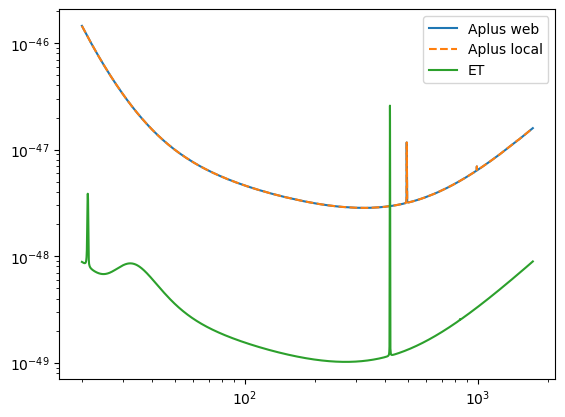

In [25]:
plt.loglog(f_all,PSD_H1,label='Aplus web')
plt.loglog(f_all,PSD_H1_local,ls='--',label='Aplus local')
plt.loglog(f_all,PSD_ET1,label='ET')
plt.legend()